In [31]:
from Kea.utils import plotting
import numpy as np
import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import scipy

c = plotting.COLOR_CYCLE_6

from sympy import *
from sympy.core import S

In [32]:

k = symbols('omega', positive=True, real=True)
l = symbols('tau', positive=True, real=True)

nu = symbols('alpha', positive=True, real=True)

a = symbols('A', positive=True, real=True)
#a = sqrt(pi) * gamma(nu + S(1)/S(2))/gamma(nu)

E = (a/k)**(nu)

display(E.simplify())

#R = integrate(E * cos(k * l), (k, 0, oo))
#display(R.simplify())

#SF = S(2) * limit(R, l, 0) - S(2) * R
#limit(R, l, 0) = 1
#display(SF.simplify())

# Gives the same thing
SF2 = 2 * integrate((1-cos(k*l))*E, (k, 0, oo))
display(SF2.simplify())

b = symbols('b', positive=True, real=True)

eq_E = (1/b) * S(1)/S(2) * l**2 * diff(SF2, l)

display(eq_E.simplify())


(A/omega)**alpha

2*A**alpha*Piecewise((-2*sqrt(pi)*(tau**2/4)**(alpha/2 + 1/2)*gamma(1/2 - alpha/2)/(tau**2*gamma(alpha/2)), (alpha > 1) & (alpha < 1)), (Integral((1 - cos(omega*tau))/omega**alpha, (omega, 0, oo)), True))

Piecewise((2*sqrt(pi)*(A*tau)**alpha*gamma((3 - alpha)/2)/(2**alpha*b*gamma(alpha/2)), (alpha > 1) & (alpha < 3)), (A**alpha*tau**2*Integral(omega**(1 - alpha)*sin(omega*tau), (omega, 0, oo))/b, True))

In [33]:
valid = eq_E.simplify().args[0][0].subs({l: b/k})

eq = Eq(valid, E)
display(eq)
points = solve(eq, b)
for p in points:
    display(p)


Eq(2*sqrt(pi)*(A*b/omega)**alpha*gamma((3 - alpha)/2)/(2**alpha*b*gamma(alpha/2)), (A/omega)**alpha)

2**(alpha/(alpha - 1))*(gamma(alpha/2 + 1)/(sqrt(pi)*alpha))**(1/(alpha - 1))/gamma(3/2 - alpha/2)**(1/(alpha - 1))

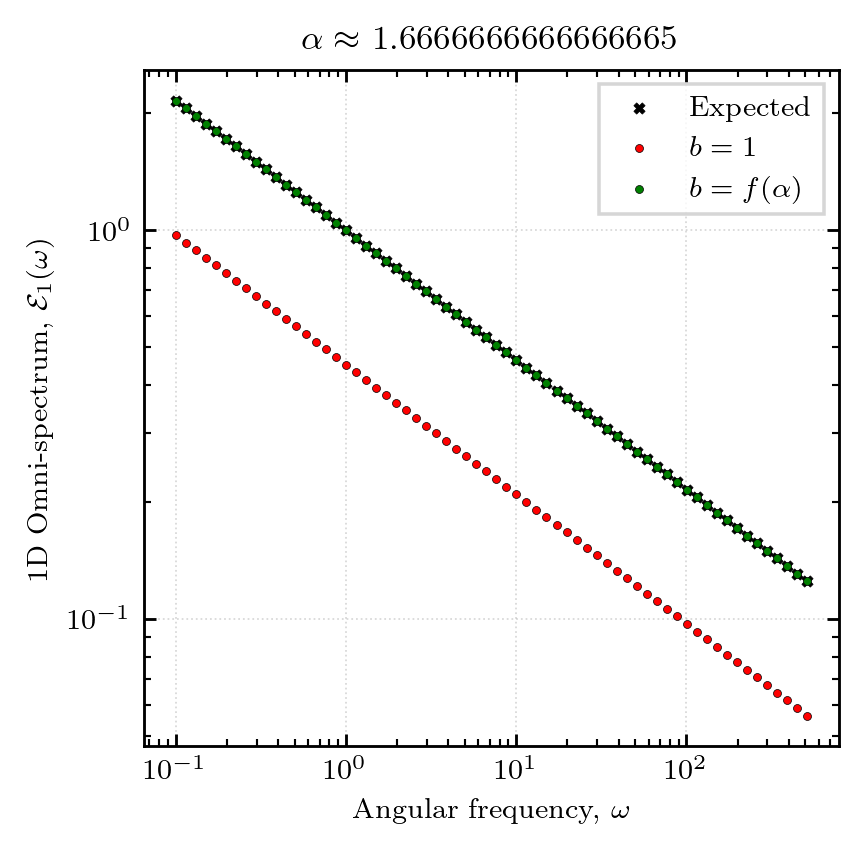

In [34]:

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

_k = np.exp(np.linspace(np.log(0.1), np.log(512), 64))
_nu = 1./3.

for __k in _k:
    val = E.subs({k: __k, nu: _nu, a: 1.}).evalf()
    ax.scatter(__k, val, marker='X', s=10., color='black', zorder=2, linewidth=0.2, edgecolor='black')

    val1 = valid.subs({k: __k, nu: _nu, b: 1., a: 1.}).evalf()
    ax.scatter(__k, val1, marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='black')

    val2 = valid.subs({k: __k, nu: _nu, b: p.subs({nu: _nu}), a: 1.}).evalf()
    ax.scatter(__k, val2, marker='o', s=5., color='green', zorder=2, linewidth=0.2, edgecolor='black')

ax.loglog()

ax.scatter([], [], marker='X', s=10., color='black', zorder=2, linewidth=0.2, edgecolor='black', label=r'Expected')
ax.scatter([], [], marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='black', label=r'$b=1$')
ax.scatter([], [], marker='o', s=5., color='green', zorder=2, linewidth=0.2, edgecolor='black', label=r'$b = f(\alpha)$')

ax.legend(frameon=True, fancybox=False)

ax.set_title(r'$\alpha \approx$ %s' % (1. + 2.*_nu))

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_ylabel(r'1D Omni-spectrum, $\mathcal{E}_1(\omega)$')
ax.set_xlabel(r'Angular frequency, $\omega$')

#ax.set_ylim((1e-6, 1e1))

fig.savefig('plots/equiv_sf_pure_pwrl_ex.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
fig.savefig('plots/equiv_sf_pure_pwrl_ex.png', transparent=True, bbox_inches='tight', pad_inches=0)


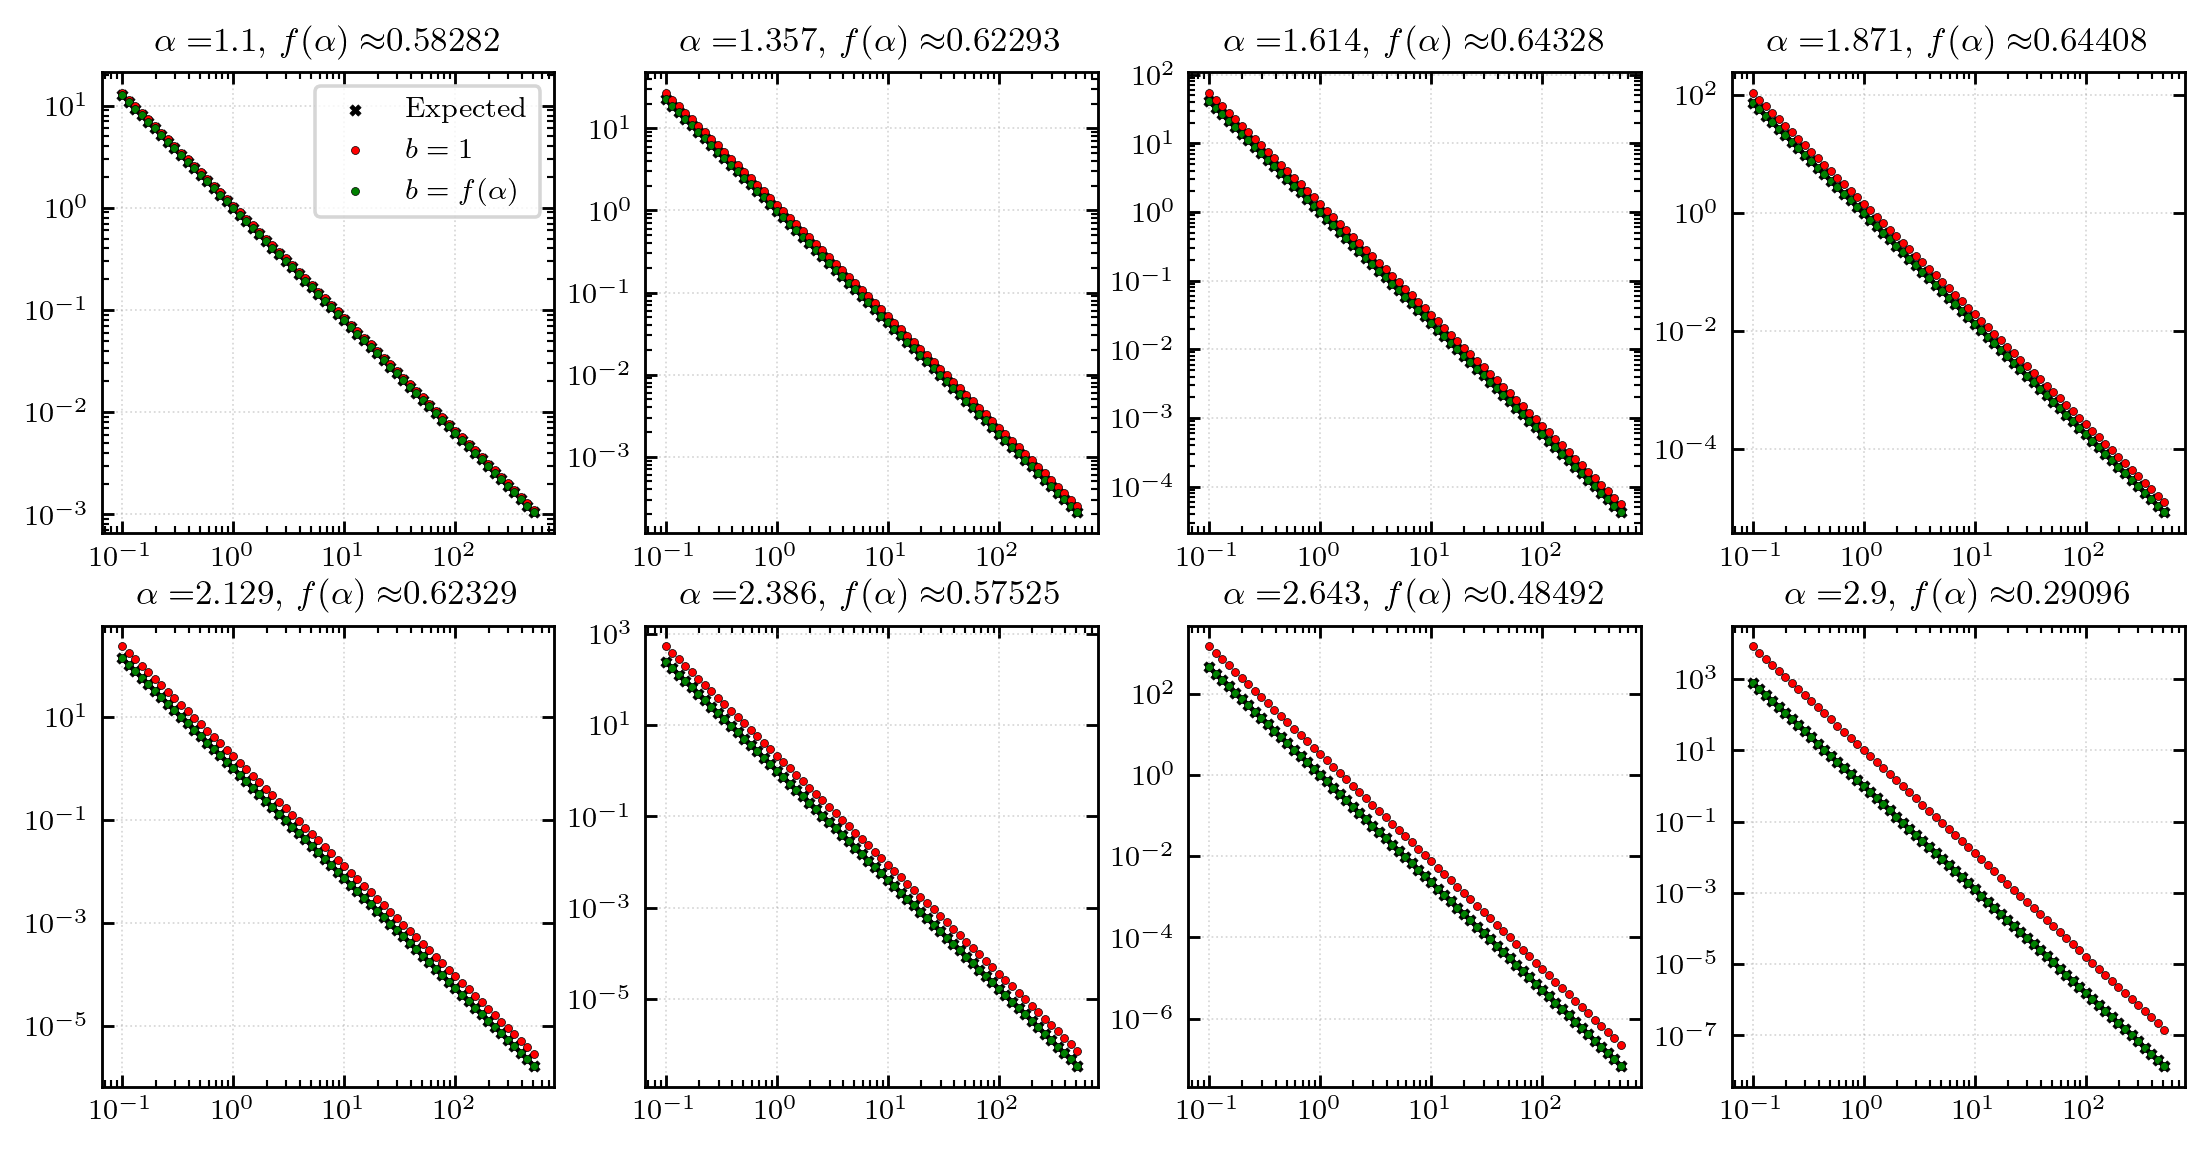

In [45]:

fig, ax = plt.subplots(2, 4, figsize=(3.5*3, 3.5*1.5), dpi=256)

alphas = np.linspace(1.1, 2.9, 8)

_k = np.exp(np.linspace(np.log(0.1), np.log(512), 64))

i = 0
for j in range(2):
    for m in range(4):
        _nu = alphas[i]

        for __k in _k:
            val = E.subs({k: __k, nu: _nu, a: 1.}).evalf()
            ax[j][m].scatter(__k, val, marker='X', s=10., color='black', zorder=2, linewidth=0.2, edgecolor='black')

            val1 = valid.subs({k: __k, nu: _nu, b: 1., a: 1.}).evalf()
            ax[j][m].scatter(__k, val1, marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='black')

            val2 = valid.subs({k: __k, nu: _nu, b: p.subs({nu: _nu}), a: 1.}).evalf()
            ax[j][m].scatter(__k, val2, marker='o', s=5., color='green', zorder=2, linewidth=0.2, edgecolor='black')
        ax[j][m].set_title(r'$\alpha=$%s, $f(\alpha)\approx$%s' % (_nu.round(decimals=3), np.float64(p.subs({nu: _nu}).evalf()).round(decimals=5)))

        i = i + 1

for _axx in ax:
    for axx in _axx:
        axx.set_xscale('log')
        axx.set_yscale('log')
        axx.yaxis.set_ticks_position('both')
        axx.xaxis.set_ticks_position('both')
        axx.tick_params(axis='y', direction='in')
        axx.tick_params(axis='y', direction='in', which='minor')
        axx.tick_params(axis='x', direction='in')
        axx.tick_params(axis='x', direction='in', which='minor')
        axx.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax[0][0].scatter([], [], marker='X', s=10., color='black', zorder=2, linewidth=0.2, edgecolor='black', label=r'Expected')
ax[0][0].scatter([], [], marker='o', s=5., color='red', zorder=2, linewidth=0.2, edgecolor='black', label=r'$b=1$')
ax[0][0].scatter([], [], marker='o', s=5., color='green', zorder=2, linewidth=0.2, edgecolor='black', label=r'$b = f(\alpha)$')
ax[0][0].legend()

fig.savefig('plots/equiv_sf_pure_pwrl.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
fig.savefig('plots/equiv_sf_pure_pwrl.png', transparent=True, bbox_inches='tight', pad_inches=0)
